In [ ]:
import pandas as pd

summary_path = "summaries/summary_with_noisy.csv"  # or "all_results.csv"

df = pd.read_csv(summary_path)

# Make sure numeric columns are actually numeric
numeric_cols = [
    "Noise Level",
    "MSE Loss",
    "Relative L2 Loss",
    "Physics Loss",
    ""
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Add degradation columns per model/run_folder
df = df.sort_values(["run_folder", "Noise Level"]).reset_index(drop=True)

# Get baseline error at noise_level == 0 for each model
baseline = (
    df[df["Noise Level"] == 0.0]
    .set_index("run_folder")[["MSE Loss", "Relative L2 Loss"]]
    .rename(columns={
        "MSE Loss": "MSE Loss baseline",
        "Relative L2 Loss": "Relative L2 Loss baseline",
    })
)

# Attach baseline values to every row
df = df.join(baseline, on="run_folder")

# Compute degradation
df["MSE Degradation"] = (
    (df["MSE Loss"] - df["MSE Loss baseline"])
    / df["MSE Loss baseline"]
)

df["Relative L2 Degradation"] = (
    (df["Relative L2 Loss"] - df["Relative L2 Loss baseline"])
    / df["Relative L2 Loss baseline"]
)

# Optional: remove helper baseline columns
df = df.drop(columns=["MSE Loss baseline", "Relative L2 Loss baseline"])

models = {}

for run_folder, group in df.groupby("run_folder"):
    group = group.sort_values("Noise Level").reset_index(drop=True)
    models[run_folder] = {
        "result_folder": group["result_folder"].iloc[0],
        "metrics": {
            "noise_level": group["Noise Level"].to_numpy(),
            "mse": group["MSE Loss"].to_numpy(),
            "relative_l2": group["Relative L2 Loss"].to_numpy(),
            "physics": group["Physics Loss"].to_numpy(),
            "mse_degradation": group["MSE Degradation"].to_numpy(),
            "relative_l2_degradation": group["Relative L2 Degradation"].to_numpy(),
        },
        "df": group,
    }
# df.to_csv(summary_path.replace(".csv", "_with_degradation.csv"), index=False)

: 

In [ ]:
for run_folder, data in models.items():
    print(f"Model: {run_folder}")
    print(data["df"][["Noise Level", "MSE Loss", "Relative L2 Loss", "MSE Degradation", "Relative L2 Degradation", "Physics Loss"]])
    print("\n")
    break


: 

In [ ]:
import matplotlib.pyplot as plt
def plot_metric(models, metric_key, ylabel, title):
    plt.figure(figsize=(12, 5))

    for run_folder, data in models.items():
        plt.plot(
            data["metrics"]["noise_level"][:-2],
            data["metrics"][metric_key][:-2],
            marker="o",
            label=run_folder,
        )

    plt.xlabel("Noise Level")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()
    
def plot_metric_log(models, metric_key, ylabel, title):
    plt.figure(figsize=(12, 5))

    for run_folder, data in models.items():
        plt.plot(
            data["metrics"]["noise_level"],
            1 + data["metrics"][metric_key],  # Shift to avoid log(0)
            marker="o",
            label=run_folder,
        )

    plt.xlabel("Noise Level")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.yscale("log")
    plt.grid(True, which="both")
    plt.legend()
    plt.show()
plot_metric(models, "mse_degradation", "MSE Degradation", "MSE Degradation vs Noise Level")
plot_metric(models, "relative_l2_degradation", "Relative L2 Degradation", "Relative L2 Degradation vs Noise Level")

: 

In [ ]:
plot_metric(models, "mse", "MSE Loss", "MSE Loss vs Noise Level")
plot_metric(models, "relative_l2", "Relative L2 Loss", "Relative L2 Loss vs Noise Level")

: 

In [ ]:
plot_metric_log(models, "mse", "MSE Loss (log scale)", "MSE Loss vs Noise Level (Log Scale)")

: 

In [ ]:
plot_metric(models, "physics", "Physics Loss", "Physics Loss vs Noise Level")

: 

In [ ]:
import pandas as pd

# Path to your CSV file
csv_path = "final_summary_experiment1.csv"  # change this to your file name/path

# Load CSV
df = pd.read_csv(csv_path)

# Make sure numeric columns are parsed correctly
numeric_cols = [
    "Noise Level",
    "MSE Loss",
    "Relative L2 Loss",
    "Physics Loss",
    "Correlation Indicator",
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Metrics to average over seeds
metric_cols = [
    "MSE Loss",
    "Relative L2 Loss",
    "Physics Loss",
    "Correlation Indicator",
]

# Group by model/run type and noise level
summary = (
    df.groupby(["run_folder", "Noise Level"])[metric_cols]
    .agg(["mean", "std"])
    .reset_index()
)

# Flatten column names
summary.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in summary.columns
]

summary.head()

: 

In [3]:
summary.to_csv("results_mean_std_over_seeds.csv", index=False)

In [2]:
summary = summary.rename(columns={
    "MSE Loss_mean": "mse_mean",
    "MSE Loss_std": "mse_std",
    "Relative L2 Loss_mean": "rel_l2_mean",
    "Relative L2 Loss_std": "rel_l2_std",
    "Physics Loss_mean": "physics_mean",
    "Physics Loss_std": "physics_std",
    "Correlation Indicator_mean": "corr_mean",
    "Correlation Indicator_std": "corr_std",
})
name_map = {
    "fno_no_physics": "FNO",
    "fno_no_physics_seed": "FNO",
    "fno_no_scaling": "PINO",
    "fno_no_scaling_seed": "PINO",
    "noisy_fno": "FNO + noise augmentation",
    "noisy_fno_seed": "FNO + noise augmentation",
    "noisy_pino": "PINO + noise augmentation",
    "noisy_pino_seed": "PINO + noise augmentation",
    "physics_only_noisy": "Physics-only + noise augmentation",
    "physics_only": "Physics-only",
}

summary["model_name"] = summary["run_folder"].replace(name_map)

In [6]:
# select FNO and PINO at noise 0.0 and print metrics (mean ± std)
target = ["FNO", "PINO", "Physics-only"]
sel = summary[(summary["Noise Level"] == 0.0) & (summary["model_name"].isin(target))]

for _, row in sel.iterrows():
    print(row["model_name"])
    print(f"  MSE: {row['mse_mean']:.4f} ± {row['mse_std']:.4f}")
    print(f"  Relative L2: {row['rel_l2_mean']:.4f} ± {row['rel_l2_std']:.4f}")
    print(f"  Physics Loss: {row['physics_mean']:.4f} ± {row['physics_std']:.4f}")
    print(f"  Correlation: {row['corr_mean']:.4f} ± {row['corr_std']:.4f}")
    print()
print()

FNO
  MSE: 0.4208 ± 0.0163
  Relative L2: 0.0661 ± 0.0014
  Physics Loss: 0.2427 ± 0.0016
  Correlation: 0.9894 ± 0.0004

PINO
  MSE: 0.8260 ± 0.0338
  Relative L2: 0.0938 ± 0.0023
  Physics Loss: 0.3172 ± 0.0124
  Correlation: 0.9792 ± 0.0009

Physics-only
  MSE: 1.0321 ± 0.0302
  Relative L2: 0.1121 ± 0.0020
  Physics Loss: 0.1263 ± 0.0022
  Correlation: 0.9803 ± 0.0004




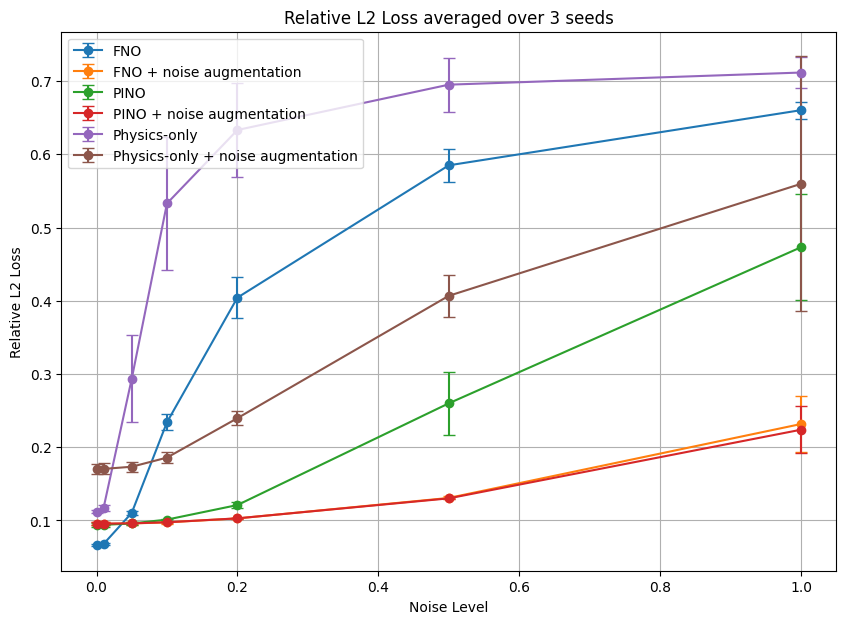

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))

for run_name, group in summary.groupby("model_name"):
    group = group.sort_values("Noise Level")

    plt.errorbar(
        group["Noise Level"],
        group["rel_l2_mean"],
        yerr=group["rel_l2_std"],
        marker="o",
        capsize=4,
        label=run_name,
    )

plt.xlabel("Noise Level")
plt.ylabel("Relative L2 Loss")
plt.title("Relative L2 Loss averaged over 3 seeds")
plt.legend()
plt.grid(True)
plt.show()

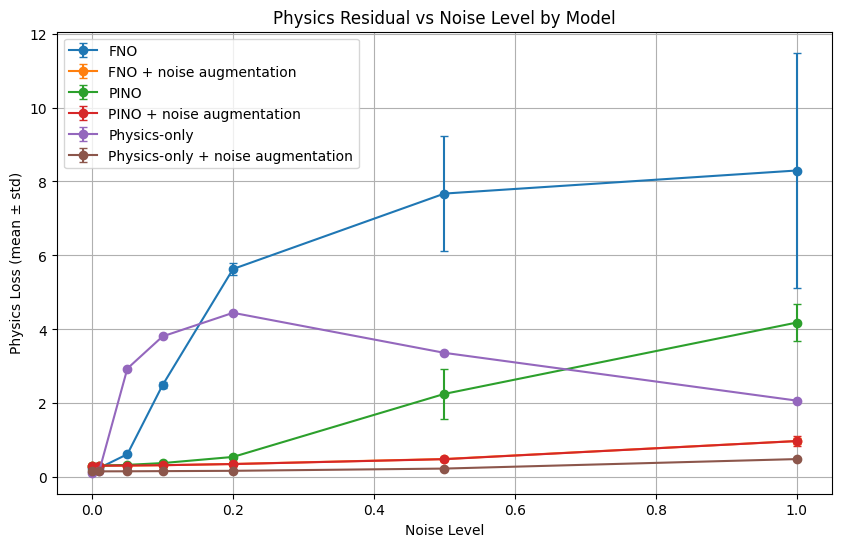

In [13]:
plt.figure(figsize=(10, 6))
for model_name, group in summary.groupby("model_name"):
    g = group.sort_values("Noise Level")
    plt.errorbar(
        g["Noise Level"],
        g["physics_mean"],
        yerr=g["physics_std"].fillna(0),
        marker="o",
        capsize=3,
        label=model_name,
    )

plt.xlabel("Noise Level")
plt.ylabel("Physics Loss (mean ± std)")
plt.title("Physics Residual vs Noise Level by Model")
plt.grid(True)
plt.legend()
plt.show()

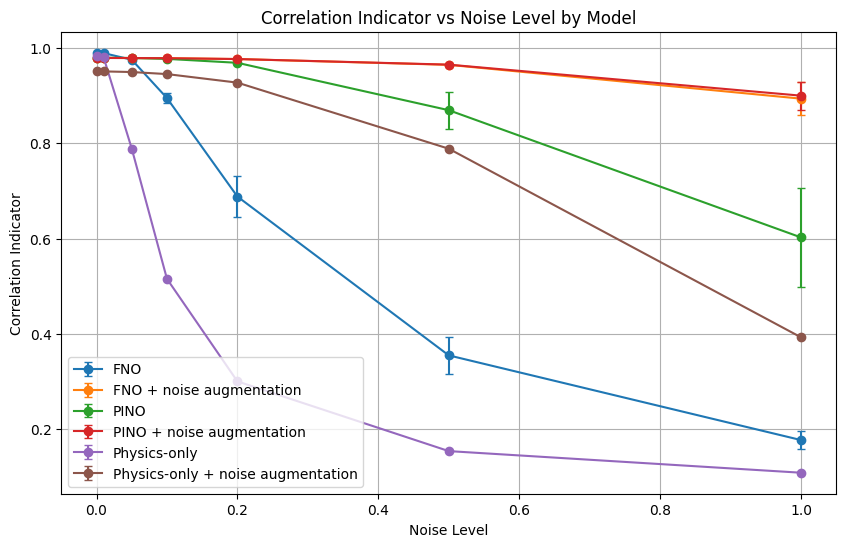

In [14]:
plt.figure(figsize=(10, 6))

for model_name, group in summary.groupby("model_name"):
    g = group.sort_values("Noise Level")
    plt.errorbar(
        g["Noise Level"],
        g["corr_mean"],
        yerr=g["corr_std"].fillna(0),
        marker="o",
        capsize=3,
        label=model_name,
    )

plt.xlabel("Noise Level")
plt.ylabel("Correlation Indicator")
plt.title("Correlation Indicator vs Noise Level by Model")
plt.grid(True)
plt.legend()
plt.show()

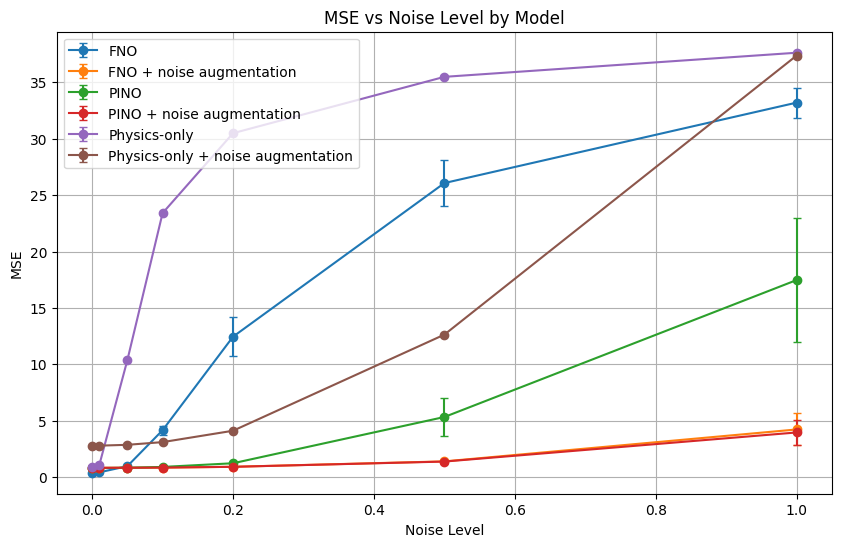

In [15]:
plt.figure(figsize=(10, 6))

for model_name, group in summary.groupby("model_name"):
    g = group.sort_values("Noise Level")
    plt.errorbar(
        g["Noise Level"],
        g["mse_mean"],
        yerr=g["mse_std"].fillna(0),
        marker="o",
        capsize=3,
        label=model_name,
    )

plt.xlabel("Noise Level")
plt.ylabel("MSE")
plt.title("MSE vs Noise Level by Model")
plt.grid(True)
plt.legend()
plt.show()